# 01 · Análisis exploratorio: lluvia y mortalidad en carreteras del Perú

**Curso:** Inteligencia Artificial Aplicada (1INF62) · PUCP · 2026-2 · Entregable parcial (Semana 8)

**Pregunta del proyecto:** ¿cuánta mortalidad hay en una carretera según el nivel de precipitación?

**Qué hace este notebook**
1. Descarga el dataset *Accidentes de Tránsito en Carreteras* (SUTRAN, datosabiertos.gob.pe) a `data/raw/`.
2. Limpia y tipifica las columnas.
3. Descarga la precipitación diaria por departamento desde la API histórica de **Open-Meteo** (gratuita, sin API key) y la une con los accidentes.
4. Guarda `data/processed/accidentes_clima.csv`.
5. Hace el EDA (distribuciones, relación lluvia vs. fatalidad, controles por departamento).

> **Limitación clave (se discute en el informe):** el dataset **no trae coordenadas**, solo `DEPARTAMENTO`, `CODIGO_VIA` y `KILOMETRO`.
> Por eso la lluvia se mide en **un punto por departamento** (su capital). Es un *proxy* grueso: en departamentos grandes (Loreto, Cusco, Puno) la lluvia en la capital puede diferir mucho de la lluvia en el km del accidente.

In [1]:
import re, time, unicodedata, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

# Rutas relativas a la raíz del repo (funciona si el notebook se ejecuta desde /notebooks o desde la raíz)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW, PROC, PLOTS = ROOT / "data" / "raw", ROOT / "data" / "processed", ROOT / "results" / "plots"
for p in (RAW, PROC, PLOTS):
    p.mkdir(parents=True, exist_ok=True)

URL_ACCIDENTES = ("https://www.datosabiertos.gob.pe/sites/default/files/"
                  "Accidentes%20de%20tr%C3%A1nsito%20en%20carreteras-2020-2021-Sutran.csv")
F_ACC = RAW / "accidentes_transito_carreteras.csv"
F_CLIMA = RAW / "clima_open_meteo.csv"
print("Raíz del proyecto:", ROOT)

Raíz del proyecto: C:\Users\marco\Documents\Repositorios\Repositorios_Universidad\IAA-Grupo3


## 1. Datos de accidentes (SUTRAN)

In [2]:
# Descarga (solo si el archivo no existe). Si falla, bájalo a mano desde la página del dataset
# y guárdalo como data/raw/accidentes_transito_carreteras.csv
if not F_ACC.exists():
    r = requests.get(URL_ACCIDENTES, timeout=120)
    r.raise_for_status()
    F_ACC.write_bytes(r.content)
    print("Descargado:", F_ACC, f"({len(r.content)/1e6:.1f} MB)")
else:
    print("Usando archivo local:", F_ACC)


def leer_csv(path):
    # El CSV de SUTRAN usa ';' como separador y codificación ISO-8859-1 (latin-1).
    for enc in ("utf-8-sig", "latin-1"):
        try:
            out = pd.read_csv(path, sep=";", encoding=enc, dtype=str)
            if out.shape[1] == 1:      # por si algún día cambian el separador
                out = pd.read_csv(path, sep=None, engine="python", encoding=enc, dtype=str)
            return out
        except UnicodeDecodeError:
            continue
    raise ValueError("No se pudo leer el CSV con utf-8 ni latin-1")


def quitar_tildes(s):
    return "".join(c for c in unicodedata.normalize("NFD", str(s)) if unicodedata.category(c) != "Mn")


raw = leer_csv(F_ACC)
raw.columns = [quitar_tildes(c).strip().upper().replace(" ", "_") for c in raw.columns]

# El archivo real de SUTRAN difiere un poco del diccionario de datos:
#   CODIGO_VM-MA (encabezado con la tilde dañada)  -> CODIGO_VIA
#   FALLECIDOS / HERIDOS                            -> NUM_FALLECIDOS / NUM_HERIDOS
RENOMBRAR = {c: "CODIGO_VIA" for c in raw.columns if c.startswith("CODIGO_V")}
RENOMBRAR.update({"FALLECIDOS": "NUM_FALLECIDOS", "HERIDOS": "NUM_HERIDOS"})
raw = raw.rename(columns=RENOMBRAR)
print(raw.shape)
raw.head()

Usando archivo local: C:\Users\marco\Documents\Repositorios\Repositorios_Universidad\IAA-Grupo3\data\raw\accidentes_transito_carreteras.csv
(8155, 9)


,FECHA_CORTE,FECHA,HORA,DEPARTAMENTO,CODIGO_VIA,KILOMETRO,MODALIDAD,NUM_FALLECIDOS,NUM_HERIDOS
0,20211222,20200101,05:40,LIMA,PE-1S,24,DESPISTE,0,0
1,20211222,20200101,16:30,CAJAMARCA,PE-3N,74,DESPISTE,0,0
2,20211222,20200101,07:45,PASCO,PE-3N,103,DESPISTE,0,1
3,20211222,20200101,18:30,CAJAMARCA,PE-08,111,DESPISTE,0,2
4,20211222,20200101,18:40,LIMA,PE-1N,174,DESPISTE,0,5


In [3]:
ESPERADAS = {"FECHA", "HORA", "DEPARTAMENTO", "CODIGO_VIA", "KILOMETRO", "MODALIDAD", "NUM_FALLECIDOS", "NUM_HERIDOS"}
faltan = ESPERADAS - set(raw.columns)
assert not faltan, f"Faltan columnas en el CSV: {faltan}. Columnas encontradas: {list(raw.columns)}"
raw.isna().mean().round(4).to_frame("proporción_nulos")

,proporción_nulos
FECHA_CORTE,0.0
FECHA,0.0
HORA,0.0
DEPARTAMENTO,0.0
CODIGO_VIA,0.0
KILOMETRO,0.0
MODALIDAD,0.0
NUM_FALLECIDOS,0.0
NUM_HERIDOS,0.0


### 1.1 Limpieza y tipificación

In [4]:
def parse_fecha(s):
    s = s.astype(str).str.strip().str.split(" ").str[0]
    out = pd.to_datetime(s, format="%Y%m%d", errors="coerce")
    for fmt in ("%d/%m/%Y", "%Y-%m-%d", "%d-%m-%Y", "%m/%d/%Y"):
        m = out.isna()
        if not m.any():
            break
        out[m] = pd.to_datetime(s[m], format=fmt, errors="coerce")
    return out


def parse_hora(s):
    # Devuelve la hora entera (0-23). Acepta 'HH:MM:SS', 'HH:MM' o numérico HHMM / HHMMSS.
    s = s.astype(str).str.strip()
    t = pd.to_datetime(s, format="%H:%M:%S", errors="coerce")
    m = t.isna()
    t[m] = pd.to_datetime(s[m], format="%H:%M", errors="coerce")
    h = t.dt.hour.astype("float")
    m = h.isna() & s.str.fullmatch(r"\d{1,6}")
    if m.any():
        num = pd.to_numeric(s[m])
        largo = s[m].str.len()
        h[m] = np.where(largo <= 4, num // 100, num // 10000)
    h[(h < 0) | (h > 23)] = np.nan
    return h


def parse_km(s):
    # Toma el primer número de la cadena (admite coma decimal)
    s = s.astype(str).str.replace(",", ".", regex=False)
    return pd.to_numeric(s.str.extract(r"(\d+\.?\d*)")[0], errors="coerce")


df = raw.copy()
df["FECHA"] = parse_fecha(df["FECHA"])
df["HORA_INT"] = parse_hora(df["HORA"])
df["KILOMETRO"] = parse_km(df["KILOMETRO"])
for c in ("NUM_FALLECIDOS", "NUM_HERIDOS"):
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Fechas inválidas:", df["FECHA"].isna().sum(),
      "| horas inválidas:", df["HORA_INT"].isna().sum(),
      "| fallecidos nulos:", df["NUM_FALLECIDOS"].isna().sum())

df = df.dropna(subset=["FECHA", "NUM_FALLECIDOS"]).copy()
df["NUM_HERIDOS"] = df["NUM_HERIDOS"].fillna(0)
df["NUM_FALLECIDOS"] = df["NUM_FALLECIDOS"].astype(int)

# Nombres de departamento normalizados (para cruzar con el clima)
ALIAS = {"LIMA METROPOLITANA": "LIMA", "LIMA PROVINCIAS": "LIMA", "PROV. CONST. DEL CALLAO": "CALLAO",
         "PROVINCIA CONSTITUCIONAL DEL CALLAO": "CALLAO"}
df["DEPARTAMENTO"] = df["DEPARTAMENTO"].map(lambda x: quitar_tildes(x).strip().upper()).replace(ALIAS)
df["MODALIDAD"] = df["MODALIDAD"].fillna("N.I.").map(lambda x: quitar_tildes(x).strip().upper())
df["CODIGO_VIA"] = df["CODIGO_VIA"].fillna("N.I.").astype(str).str.strip().str.upper()

# Variables derivadas
df["ANIO"] = df["FECHA"].dt.year
df["MES"] = df["FECHA"].dt.month
df["DIA_SEMANA"] = df["FECHA"].dt.dayofweek          # 0 = lunes
df["ES_FATAL"] = (df["NUM_FALLECIDOS"] > 0).astype(int)

sin_depto = (df["DEPARTAMENTO"] == "N.I.").sum()
df = df[df["DEPARTAMENTO"] != "N.I."]
print(f"Registros sin departamento descartados: {sin_depto}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Registros tras limpieza: {len(df):,} | periodo: {df.FECHA.min().date()} → {df.FECHA.max().date()}")
df.head()

Fechas inválidas: 0 | horas inválidas: 88 | fallecidos nulos: 3
Registros sin departamento descartados: 7
Registros tras limpieza: 8,110 | periodo: 2020-01-01 → 2021-09-30


,FECHA_CORTE,FECHA,HORA,DEPARTAMENTO,CODIGO_VIA,KILOMETRO,MODALIDAD,NUM_FALLECIDOS,NUM_HERIDOS,HORA_INT,ANIO,MES,DIA_SEMANA,ES_FATAL
0,20211222,2020-01-01,05:40,LIMA,PE-1S,24.0,DESPISTE,0,0.0,5.0,2020,1,2,0
1,20211222,2020-01-01,16:30,CAJAMARCA,PE-3N,74.0,DESPISTE,0,0.0,16.0,2020,1,2,0
2,20211222,2020-01-01,07:45,PASCO,PE-3N,103.0,DESPISTE,0,1.0,7.0,2020,1,2,0
3,20211222,2020-01-01,18:30,CAJAMARCA,PE-08,111.0,DESPISTE,0,2.0,18.0,2020,1,2,0
4,20211222,2020-01-01,18:40,LIMA,PE-1N,174.0,DESPISTE,0,5.0,18.0,2020,1,2,0


## 2. Clima: precipitación diaria por departamento (Open-Meteo)

In [5]:
# Coordenadas APROXIMADAS de la capital de cada departamento (lat, lon).
# El dataset no trae coordenadas, así que este es el punto de referencia de lluvia por departamento.
COORD = {
    "AMAZONAS": (-6.23, -77.87), "ANCASH": (-9.53, -77.53), "APURIMAC": (-13.64, -72.88),
    "AREQUIPA": (-16.40, -71.54), "AYACUCHO": (-13.16, -74.22), "CAJAMARCA": (-7.16, -78.51),
    "CALLAO": (-12.05, -77.12), "CUSCO": (-13.53, -71.97), "HUANCAVELICA": (-12.79, -74.98),
    "HUANUCO": (-9.93, -76.24), "ICA": (-14.07, -75.73), "JUNIN": (-12.07, -75.21),
    "LA LIBERTAD": (-8.11, -79.03), "LAMBAYEQUE": (-6.77, -79.84), "LIMA": (-12.05, -77.04),
    "LORETO": (-3.75, -73.25), "MADRE DE DIOS": (-12.59, -69.19), "MOQUEGUA": (-17.19, -70.93),
    "PASCO": (-10.68, -76.26), "PIURA": (-5.19, -80.63), "PUNO": (-15.84, -70.02),
    "SAN MARTIN": (-6.03, -76.97), "TACNA": (-18.01, -70.25), "TUMBES": (-3.57, -80.45),
    "UCAYALI": (-8.38, -74.55),
}
sin_coord = sorted(set(df["DEPARTAMENTO"]) - set(COORD))
print("Departamentos sin coordenadas (no tendrán clima):", sin_coord)
print("Registros afectados:", df["DEPARTAMENTO"].isin(sin_coord).sum())

Departamentos sin coordenadas (no tendrán clima): []
Registros afectados: 0


In [6]:
API = "https://archive-api.open-meteo.com/v1/archive"   # API histórica gratuita, sin API key


def bajar_clima(nombre, lat, lon, ini, fin, intentos=5):
    params = dict(latitude=lat, longitude=lon, start_date=ini, end_date=fin,
                  daily="precipitation_sum,rain_sum,precipitation_hours", timezone="America/Lima")
    for k in range(intentos):
        r = requests.get(API, params=params, timeout=60)
        if r.status_code == 200:
            out = pd.DataFrame(r.json()["daily"]).rename(columns={"time": "FECHA"})
            out["DEPARTAMENTO"] = nombre
            return out
        time.sleep(3 * (k + 1))          # espera creciente si la API limita las peticiones
    raise RuntimeError(f"Open-Meteo falló para {nombre}: {r.status_code} {r.text[:200]}")


ini, fin = df["FECHA"].min().strftime("%Y-%m-%d"), df["FECHA"].max().strftime("%Y-%m-%d")

if F_CLIMA.exists():
    clima = pd.read_csv(F_CLIMA, parse_dates=["FECHA"])
    print("Clima cargado desde caché:", F_CLIMA)
else:
    partes = []
    for dep in sorted(set(df["DEPARTAMENTO"]) & set(COORD)):
        lat, lon = COORD[dep]
        partes.append(bajar_clima(dep, lat, lon, ini, fin))
        print("OK", dep)
        time.sleep(1)
    clima = pd.concat(partes, ignore_index=True)
    clima.to_csv(F_CLIMA, index=False)
    clima["FECHA"] = pd.to_datetime(clima["FECHA"])

print(clima.shape, "| rango:", clima.FECHA.min().date(), "→", clima.FECHA.max().date())
clima.describe().round(2)

Clima cargado desde caché: C:\Users\marco\Documents\Repositorios\Repositorios_Universidad\IAA-Grupo3\data\raw\clima_open_meteo.csv
(15975, 5) | rango: 2020-01-01 → 2021-09-30


,FECHA,precipitation_sum,rain_sum,precipitation_hours
count,15975,15975.00,15975.00,15975.00
mean,2020-11-15 00:00:00,2.09,2.07,3.95
min,2020-01-01 00:00:00,0.00,0.00,0.00
25%,2020-06-08 00:00:00,0.00,0.00,0.00
50%,2020-11-15 00:00:00,0.10,0.10,1.00
75%,2021-04-24 00:00:00,1.90,1.90,7.00
max,2021-09-30 00:00:00,160.60,160.60,24.00
std,NaN,5.24,5.21,5.40


In [7]:
data = df.merge(clima, on=["DEPARTAMENTO", "FECHA"], how="left")
print(f"Accidentes con dato de lluvia: {data.precipitation_sum.notna().mean():.1%}")

data.to_csv(PROC / "accidentes_clima.csv", index=False)
print("Guardado:", PROC / "accidentes_clima.csv", data.shape)

Accidentes con dato de lluvia: 100.0%
Guardado: C:\Users\marco\Documents\Repositorios\Repositorios_Universidad\IAA-Grupo3\data\processed\accidentes_clima.csv (8110, 17)


## 3. Análisis exploratorio

### 3.1 Panorama general

Accidentes                                    8110.000
Fallecidos totales                            1375.000
Heridos totales                              10635.000
% de accidentes con ≥1 fallecido                11.726
Fallecidos por accidente (promedio)              0.170
Máx. fallecidos en un accidente                 33.000
% de accidentes en día con lluvia (>0 mm)       48.360


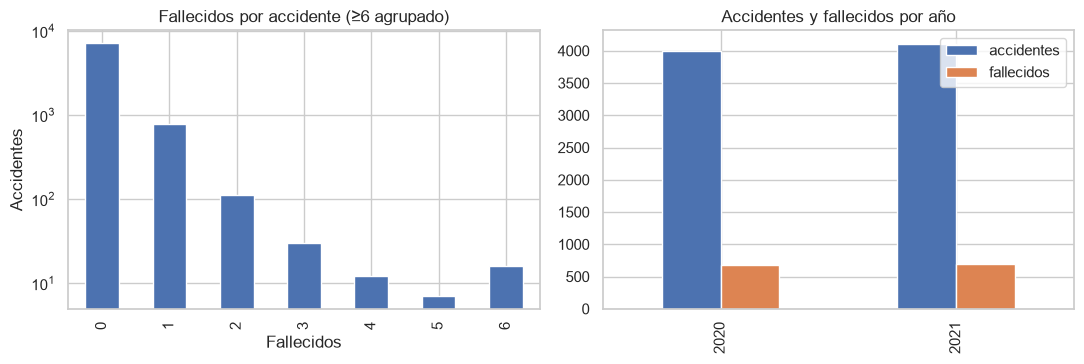

In [8]:
d = data.dropna(subset=["precipitation_sum"]).copy()

resumen = pd.Series({
    "Accidentes": len(d),
    "Fallecidos totales": d.NUM_FALLECIDOS.sum(),
    "Heridos totales": d.NUM_HERIDOS.sum(),
    "% de accidentes con ≥1 fallecido": 100 * d.ES_FATAL.mean(),
    "Fallecidos por accidente (promedio)": d.NUM_FALLECIDOS.mean(),
    "Máx. fallecidos en un accidente": d.NUM_FALLECIDOS.max(),
    "% de accidentes en día con lluvia (>0 mm)": 100 * (d.precipitation_sum > 0).mean(),
}).round(3)
print(resumen.to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
d.NUM_FALLECIDOS.clip(upper=6).value_counts().sort_index().plot.bar(ax=ax[0], color="#4C72B0")
ax[0].set(title="Fallecidos por accidente (≥6 agrupado)", xlabel="Fallecidos", ylabel="Accidentes")
ax[0].set_yscale("log")
d.groupby("ANIO").agg(accidentes=("ES_FATAL", "size"), fallecidos=("NUM_FALLECIDOS", "sum")).plot.bar(ax=ax[1])
ax[1].set(title="Accidentes y fallecidos por año", xlabel="")
plt.tight_layout(); plt.savefig(PLOTS / "eda_01_panorama.png", dpi=150); plt.show()

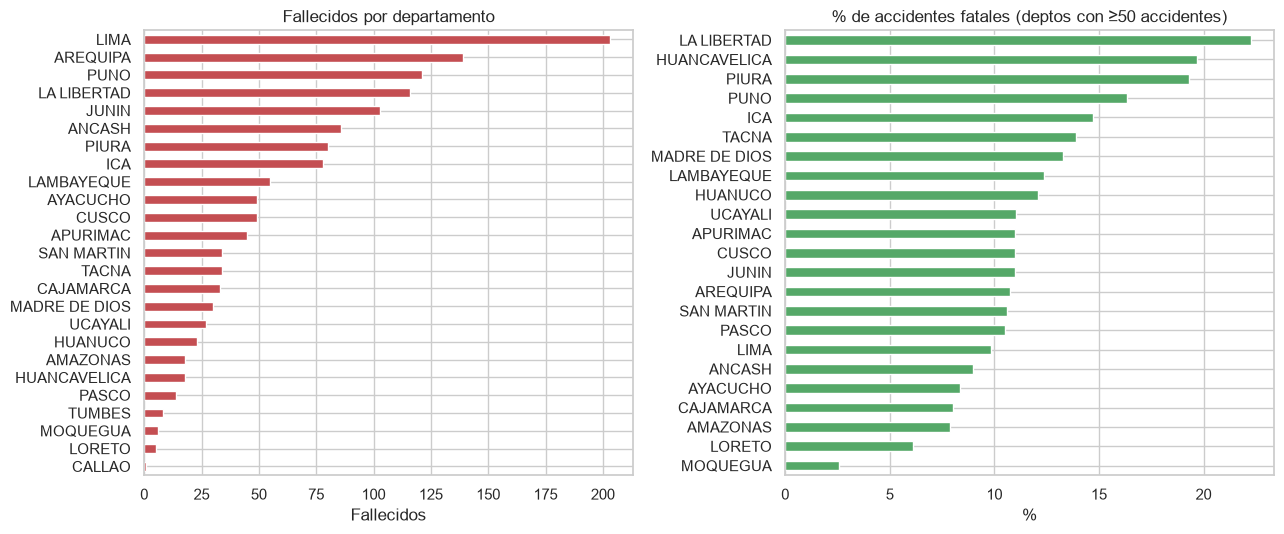

,accidentes,fallecidos,pct_fatal
MODALIDAD,,,
ATROPELLO,361,160,42.94
N.I.,26,5,19.23
CHOQUE,3605,669,13.59
ESPECIAL,186,20,8.06
DESPISTE,3804,513,7.36
VOLCADURA,128,8,4.69


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
dep = d.groupby("DEPARTAMENTO").agg(accidentes=("ES_FATAL", "size"), fallecidos=("NUM_FALLECIDOS", "sum"),
                                    tasa_fatal=("ES_FATAL", "mean")).sort_values("fallecidos")
dep["fallecidos"].plot.barh(ax=ax[0], color="#C44E52")
ax[0].set(title="Fallecidos por departamento", xlabel="Fallecidos", ylabel="")
dep.query("accidentes >= 50")["tasa_fatal"].sort_values().mul(100).plot.barh(ax=ax[1], color="#55A868")
ax[1].set(title="% de accidentes fatales (deptos con ≥50 accidentes)", xlabel="%", ylabel="")
plt.tight_layout(); plt.savefig(PLOTS / "eda_02_departamentos.png", dpi=150); plt.show()

mod = d.groupby("MODALIDAD").agg(accidentes=("ES_FATAL", "size"), fallecidos=("NUM_FALLECIDOS", "sum"),
                                 pct_fatal=("ES_FATAL", lambda x: 100 * x.mean())).round(2)
mod.sort_values("pct_fatal", ascending=False)

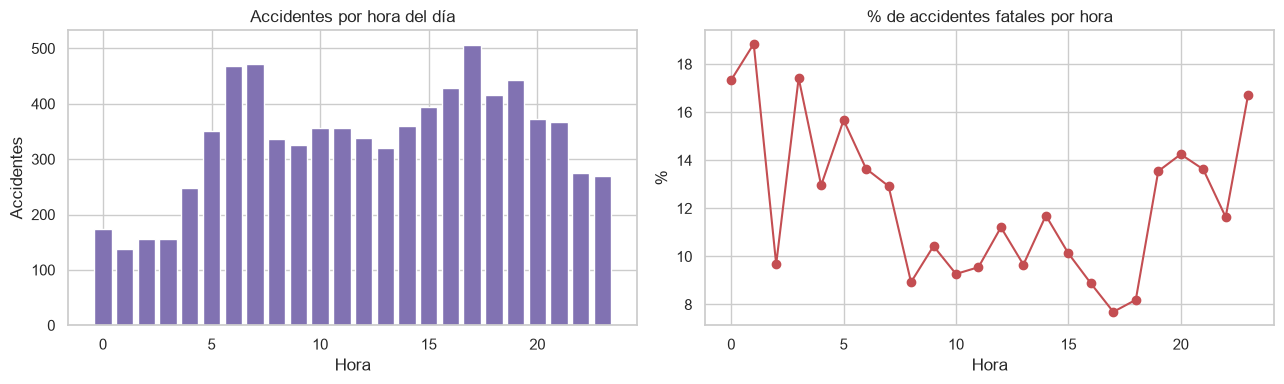

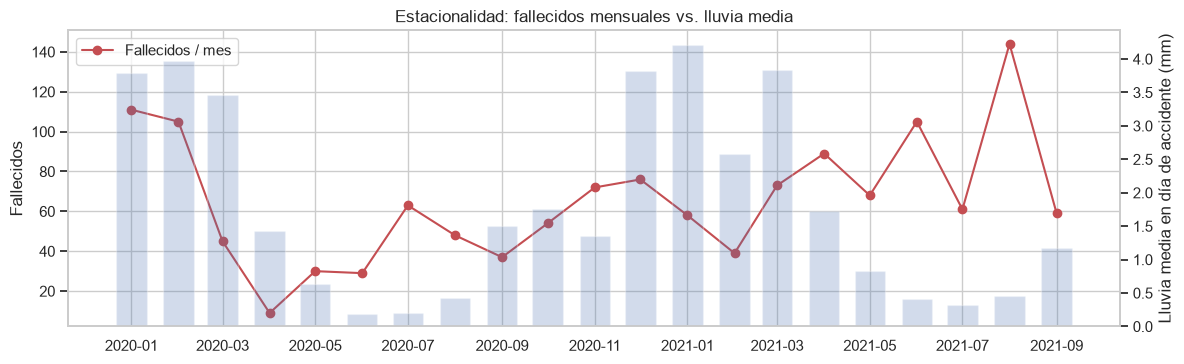

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
h = d.dropna(subset=["HORA_INT"]).groupby("HORA_INT").agg(n=("ES_FATAL", "size"), tasa=("ES_FATAL", "mean"))
ax[0].bar(h.index, h["n"], color="#8172B2"); ax[0].set(title="Accidentes por hora del día", xlabel="Hora", ylabel="Accidentes")
ax[1].plot(h.index, 100 * h["tasa"], marker="o", color="#C44E52")
ax[1].set(title="% de accidentes fatales por hora", xlabel="Hora", ylabel="%")
plt.tight_layout(); plt.savefig(PLOTS / "eda_03_hora.png", dpi=150); plt.show()

m = d.groupby(["ANIO", "MES"]).agg(accidentes=("ES_FATAL", "size"), fallecidos=("NUM_FALLECIDOS", "sum"),
                                   lluvia_media=("precipitation_sum", "mean")).reset_index()
m["periodo"] = pd.to_datetime(dict(year=m.ANIO, month=m.MES, day=1))
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(m.periodo, m.fallecidos, marker="o", label="Fallecidos / mes", color="#C44E52")
ax.set_ylabel("Fallecidos")
ax2 = ax.twinx(); ax2.bar(m.periodo, m.lluvia_media, width=20, alpha=.25, color="#4C72B0")
ax2.set_ylabel("Lluvia media en día de accidente (mm)"); ax2.grid(False)
ax.set_title("Estacionalidad: fallecidos mensuales vs. lluvia media"); ax.legend(loc="upper left")
plt.tight_layout(); plt.savefig(PLOTS / "eda_04_estacionalidad.png", dpi=150); plt.show()

### 3.2 Lluvia vs. mortalidad (núcleo del proyecto)

count    8110.00
mean        1.94
std         4.37
min         0.00
25%         0.00
50%         0.00
75%         1.60
max        68.70


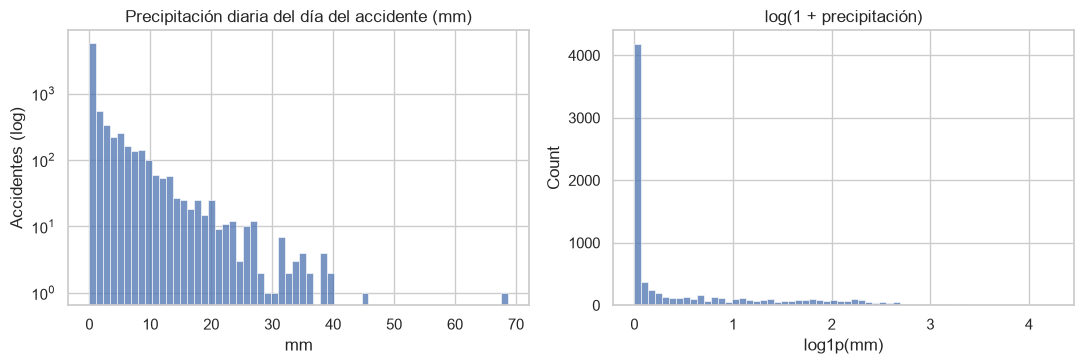

In [11]:
print(d.precipitation_sum.describe().round(2).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
sns.histplot(d.precipitation_sum, bins=60, ax=ax[0], color="#4C72B0"); ax[0].set_yscale("log")
ax[0].set(title="Precipitación diaria del día del accidente (mm)", xlabel="mm", ylabel="Accidentes (log)")
sns.histplot(np.log1p(d.precipitation_sum), bins=60, ax=ax[1], color="#4C72B0")
ax[1].set(title="log(1 + precipitación)", xlabel="log1p(mm)")
plt.tight_layout(); plt.savefig(PLOTS / "eda_05_precipitacion.png", dpi=150); plt.show()

,accidentes,fatales,fallecidos,pct_fatal,fallecidos_por_accidente,ic95_inf,ic95_sup
PRECIP_BIN,,,,,,,
0 mm,4188,503,716,12.011,0.171,11.061,13.030
0–1,1557,203,280,13.038,0.180,11.456,14.802
1–5,1305,121,170,9.272,0.130,7.816,10.967
5–10,646,88,163,13.622,0.252,11.191,16.484
10–20,314,23,30,7.325,0.096,4.930,10.751
>20,100,13,16,13.000,0.160,7.757,20.981


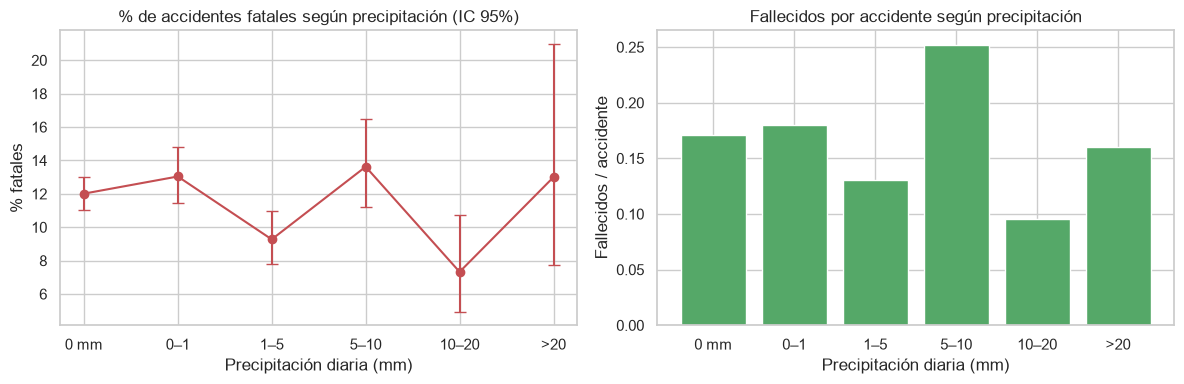

In [12]:
BINS = [-1, 0, 1, 5, 10, 20, np.inf]
ETIQ = ["0 mm", "0–1", "1–5", "5–10", "10–20", ">20"]
d["PRECIP_BIN"] = pd.cut(d.precipitation_sum, bins=BINS, labels=ETIQ)


def wilson(k, n, z=1.96):
    p = k / n
    den = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / den
    h = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return c - h, c + h


t = d.groupby("PRECIP_BIN", observed=True).agg(accidentes=("ES_FATAL", "size"), fatales=("ES_FATAL", "sum"),
                                              fallecidos=("NUM_FALLECIDOS", "sum"))
t["pct_fatal"] = 100 * t.fatales / t.accidentes
t["fallecidos_por_accidente"] = t.fallecidos / t.accidentes
lo, hi = wilson(t.fatales.values, t.accidentes.values)
t["ic95_inf"], t["ic95_sup"] = 100 * lo, 100 * hi
display(t.round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(t))
ax[0].errorbar(x, t.pct_fatal, yerr=[t.pct_fatal - t.ic95_inf, t.ic95_sup - t.pct_fatal], fmt="o-", capsize=4, color="#C44E52")
ax[0].set_xticks(x); ax[0].set_xticklabels(t.index)
ax[0].set(title="% de accidentes fatales según precipitación (IC 95%)", xlabel="Precipitación diaria (mm)", ylabel="% fatales")
ax[1].bar(x, t.fallecidos_por_accidente, color="#55A868")
ax[1].set_xticks(x); ax[1].set_xticklabels(t.index)
ax[1].set(title="Fallecidos por accidente según precipitación", xlabel="Precipitación diaria (mm)", ylabel="Fallecidos / accidente")
plt.tight_layout(); plt.savefig(PLOTS / "eda_06_lluvia_vs_fatalidad.png", dpi=150); plt.show()

In [13]:
# Pruebas estadísticas simples (asociación bruta, sin controlar por departamento ni época del año)
tabla = pd.crosstab(d.PRECIP_BIN, d.ES_FATAL)
chi2, p_chi, _, _ = stats.chi2_contingency(tabla)
rho, p_rho = stats.spearmanr(d.precipitation_sum, d.NUM_FALLECIDOS)
u, p_u = stats.mannwhitneyu(d.loc[d.ES_FATAL == 1, "precipitation_sum"],
                            d.loc[d.ES_FATAL == 0, "precipitation_sum"])
print(f"Chi² (bins de lluvia × fatal): chi2={chi2:.2f}, p={p_chi:.4g}")
print(f"Spearman (lluvia vs. fallecidos): rho={rho:.4f}, p={p_rho:.4g}")
print(f"Mann-Whitney (lluvia en accidentes fatales vs. no fatales): p={p_u:.4g}")

Chi² (bins de lluvia × fatal): chi2=18.79, p=0.002108
Spearman (lluvia vs. fallecidos): rho=-0.0145, p=0.1923
Mann-Whitney (lluvia en accidentes fatales vs. no fatales): p=0.1808


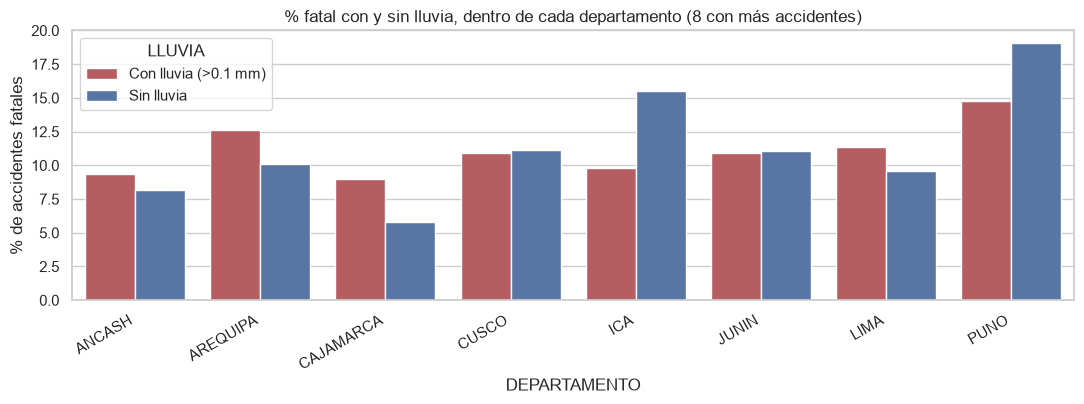

pct_fatal                            size           
LLUVIA       Con lluvia (>0.1 mm) Sin lluvia Con lluvia (>0.1 mm) Sin lluvia
DEPARTAMENTO                                                                
ANCASH                       9.35       8.20                417.0      183.0
AREQUIPA                    12.62      10.07                206.0      586.0
CAJAMARCA                    8.98       5.83                245.0      103.0
CUSCO                       10.95      11.11                274.0       72.0
ICA                          9.80      15.48                 51.0      323.0
JUNIN                       10.94      11.05                530.0      181.0
LIMA                        11.37       9.61                211.0     1342.0
PUNO                        14.79      19.05                338.0      189.0

In [14]:
# ¿Se mantiene la relación DENTRO de cada departamento? (control del efecto "geografía/clima regional")
top = d.DEPARTAMENTO.value_counts().head(8).index
d["LLUVIA"] = np.where(d.precipitation_sum > 0.1, "Con lluvia (>0.1 mm)", "Sin lluvia")
g = (d[d.DEPARTAMENTO.isin(top)].groupby(["DEPARTAMENTO", "LLUVIA"]).ES_FATAL
     .agg(["mean", "size"]).reset_index())
g["pct_fatal"] = 100 * g["mean"]
plt.figure(figsize=(11, 4.2))
sns.barplot(data=g, x="DEPARTAMENTO", y="pct_fatal", hue="LLUVIA", palette=["#C44E52", "#4C72B0"])
plt.xticks(rotation=30, ha="right"); plt.ylabel("% de accidentes fatales")
plt.title("% fatal con y sin lluvia, dentro de cada departamento (8 con más accidentes)")
plt.tight_layout(); plt.savefig(PLOTS / "eda_07_lluvia_por_departamento.png", dpi=150); plt.show()
g.pivot(index="DEPARTAMENTO", columns="LLUVIA", values=["pct_fatal", "size"]).round(2)

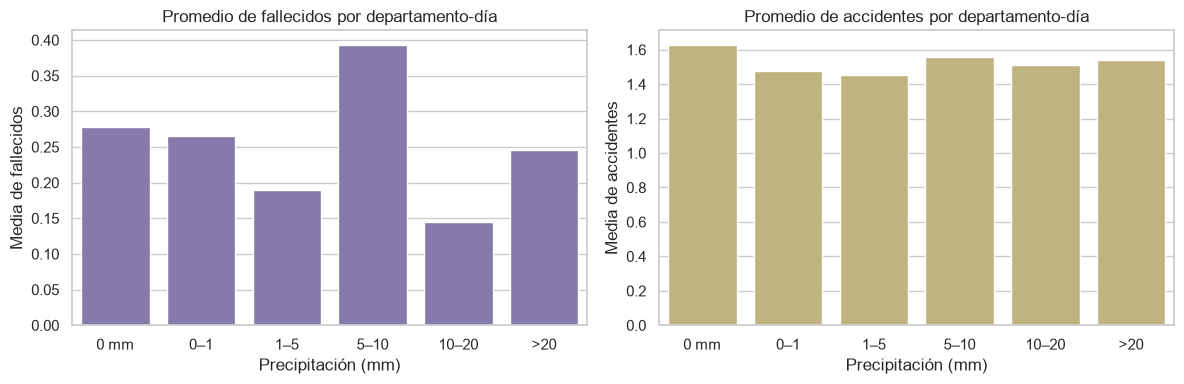

In [15]:
# Vista agregada: promedio de fallecidos y accidentes por departamento-día vs. lluvia (osea día donde hubo un accidente)
dd = (
    d.groupby(["DEPARTAMENTO", "FECHA"])
    .agg(
        accidentes=("ES_FATAL", "size"),
        fallecidos=("NUM_FALLECIDOS", "sum"),
        precip=("precipitation_sum", "first")
    )
    .reset_index()
)

dd["PRECIP_BIN"] = pd.cut(dd.precip, bins=BINS, labels=ETIQ)

# Calcular las medias por rango de precipitación para graficar
resumen_agg = dd.groupby("PRECIP_BIN", observed=False)[["fallecidos", "accidentes"]].mean().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=resumen_agg, x="PRECIP_BIN", y="fallecidos", ax=ax[0], color="#8172B2")
ax[0].set(title="Promedio de fallecidos por departamento-día", xlabel="Precipitación (mm)", ylabel="Media de fallecidos")

sns.barplot(data=resumen_agg, x="PRECIP_BIN", y="accidentes", ax=ax[1], color="#CCB974")
ax[1].set(title="Promedio de accidentes por departamento-día", xlabel="Precipitación (mm)", ylabel="Media de accidentes")

plt.tight_layout()
plt.savefig(PLOTS / "eda_08_agregado_dep_dia.png", dpi=150)
plt.show()

# Ejmeplo interpretación: 
# En un día donde hubo al menos un accidente en una región con 0 mm de lluvia, 
# el total acumulado de fallecidos en esa región durante ese día fue en promedio de 0.28.

### 3.3 Hallazgos del EDA

- **Tamaño y calidad:** 
El CSV trae 8 155 accidentes.
Tras la limpieza quedan 8 117 (se descartaron 3 sin dato de fallecidos y 35 duplicados exactos), de los cuales, 8 110 (99.9 %) tienen dato de lluvia y los 7 restantes no tienen departamento ("N.I."). Se trabaja con los 8 110.
El 98.9 % de la data procesada, tiene hora válida (87 registros "N.I.", igual que indica el diccionario), las horas inválidas no se descartan debido a que las precipitaciones son por día. 
Aunque la fecha de corte es 22/12/2021, los accidentes llegan solo hasta el 30/09/2021, así que el periodo real es 01/01/2020 – 30/09/2021.


- **Fatalidad base:** 
El 11.7 % de los accidentes tiene al menos un fallecido (≈1 de cada 9).
En total hay 1 375 fallecidos y 10 635 heridos; el promedio es 0.17 fallecidos por accidente y el máximo es 33 en un solo accidente.
El 48.4 % de los accidentes ocurrió en un día con lluvia > 0 mm, pero la mediana de lluvia es 0 mm: la mayoría de los días con lluvia son lloviznas.


- **Lluvia vs. fatalidad (bruto):** 
El % de accidentes fatales por rango de lluvia es 12.0 % (0 mm), 13.0 % (0–1), 9.3 % (1–5), 13.6 % (5–10), 7.3 % (10–20) y 13.0 % (>20).
El último rango tiene solo 100 accidentes y un IC95 % muy ancho (7.8–21.0 %). 
El chi cuadrado sí rechaza que las proporciones sean iguales (p = 0.002), pero la diferencia no sigue un orden con la lluvia: sube y baja. 
Al tratar la lluvia como variable continua no hay asociación significativa (Spearman ρ = −0.015, p = 0.19; Mann-Whitney p = 0.18).


- **Lluvia vs. fatalidad (dentro de cada departamento):**
El signo cambia según el departamento, por lo que no hay un efecto consistente. 
Con lluvia el % fatal es mayor en Cajamarca (9.0 % vs 5.8 %), Arequipa (12.6 % vs 10.1 %), Lima (11.4 % vs 9.6 %) y Áncash (9.4 % vs 8.2 %).
Con lluvia el % fatal es menor en Ica (9.8 % vs 15.5 %) y Puno (14.8 % vs 19.1 %); y prácticamente igual en Cusco y Junín. 
Hay confusión por geografía: en Lima e Ica (costa) casi todos los accidentes ocurren sin lluvia (1 342 vs 211 en Lima), mientras que en la sierra predominan los días con lluvia, y los departamentos tienen niveles de fatalidad muy distintos entre sí. Por eso el análisis bruto mezcla efecto de la lluvia con efecto del lugar.


- **Vista agregada (departamento-día):**
En los días con al menos un accidente, el promedio de fallecidos por departamento al día es 0.28 (a 0 mm), 0.27 (a 0–1mm), 0.19 (a 1–5mm), 0.39 (a 5–10mm), 0.14 (a 10–20mm) y 0.25 (>20mm).
Tampoco sigue un patrón ordenado. El pico en 5–10 mm podría deberse a pocos eventos con muchos fallecidos (hay un máximo de 33); conviene verificarlo con la mediana o sin esos casos. 
El número de accidentes por departamento-día es casi constante (≈1.5) en todos los rangos de lluvia, así que, entre los días con accidentes, la lluvia no parece cambiar cuántos se reportan.


- **Limitaciones a declarar:** lluvia medida en la capital del departamento; el dataset solo contiene accidentes (no hay exposición/tráfico); posible subregistro; periodo 2020–2021 incluye efecto pandemia.


- **Modalidad (la variable más relacionada con la fatalidad):** 
El atropello es el más letal (42.9 % fatal, 160 fallecidos en solo 361 accidentes). 
El choque concentra más fallecidos (669; 13.6 % fatal).
El despiste es el más frecuente (3 804 accidentes; 7.4 % fatal, 513 fallecidos). 
La Volcadura (4.7 %) y especial (8.1 %) son los menos letales.


- **Hora:** 
Hay más accidentes entre las 6–7 h y a las 17 h (≈ 470–500 por hora), pero son menos letales (≈ 8 % fatal a las 17–18 h). 
La madrugada y la noche son las más letales: ≈ 17–19 % fatal entre las 0 y las 3 h y ≈ 17 % a las 23 h, con pocos accidentes.


- **Departamento:** 
Lima acumula más fallecidos (≈ 200), seguido de Arequipa, Puno, La Libertad y Junín, pero esto se debe sobre todo al volumen de accidentes. 
Por tasa, los más letales son La Libertad (≈ 22 % fatal), Huancavelica (≈ 20 %), Piura (≈ 19 %) y Puno (≈ 16 %); los menos, Moquegua (≈ 3 %) y Loreto (≈ 6 %).


- **Estacionalidad:** 
La lluvia se concentra en diciembre–marzo, pero los meses con más fallecidos no coinciden con esos meses (por ejemplo, agosto de 2021 llega a ≈ 143 fallecidos con muy poca lluvia). 
Además, abril de 2020 cae a ≈ 20 fallecidos, coherente con la cuarentena por la pandemia. La movilidad es un factor de confusión en la serie temporal.



- **Limitaciones a declarar:** 
La lluvia se mide en la capital del departamento (no en el km del accidente); el dataset solo contiene accidentes (no hay tráfico ni días sin accidentes), por lo que no se puede estimar si la lluvia aumenta la frecuencia de accidentes; posible subregistro y valores "N.I."; el periodo 2020-2021 incluye el efecto de la pandemia; y 35 registros duplicados exactos fueron eliminados aunque podrían ser accidentes distintos con los mismos campos (aunque muy improbable).


- **Conclusión del EDA:** 
Con estos datos*no se observa evidencia de que la lluvia, medida a nivel diario por departamento, aumente o reduzca la fatalidad de un accidente. Las variables que más se asocian con la fatalidad son la modalidad (sobre todo atropello), la hora (madrugada/noche) y el departamento.